## Import des bibliothèques

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

### Question 1.1

In [3]:
# Convertis le json en dict
with open("trajets.json") as f:
    data = json.load(f)

In [4]:
df = pd.DataFrame(data)
df.head(5)

,trajet_id,station_depart,station_arrivee,type_usager,duree_minutes,distance_km,heure_depart,jour_semaine,temperature_c,velo_id
0,T001,Gare Centrale,Parc Lumière,abonné,14.0,3.2,08:32,lundi,18.5,V042
1,T002,Université,NaN,occasionnel,NaN,1.8,13:15,mercredi,NaN,V017
2,T003,Hôtel de Ville,Gare Centrale,abonné,9.0,2.1,07:48,mardi,15.0,V005
3,T004,Parc Lumière,Marché Central,occasionnel,22.0,4.5,10:05,samedi,22.3,V031
4,T005,Bibliothèque,Université,abonné,7.0,1.3,09:20,jeudi,11.2,V008


### Question 1.2

In [5]:
# Nombre total de trajets
nb_trajets = len(df['trajet_id'].unique())
print(f"Nb total de trajets uniques : {nb_trajets}")

Nb total de trajets uniques : 80


In [6]:
# Liste des colonnes
print(df.columns)

Index(['trajet_id', 'station_depart', 'station_arrivee', 'type_usager',
       'duree_minutes', 'distance_km', 'heure_depart', 'jour_semaine',
       'temperature_c', 'velo_id'],
      dtype='str')


In [7]:
# Type des colonnes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   trajet_id        83 non-null     str    
 1   station_depart   83 non-null     str    
 2   station_arrivee  78 non-null     str    
 3   type_usager      83 non-null     str    
 4   duree_minutes    78 non-null     float64
 5   distance_km      83 non-null     float64
 6   heure_depart     83 non-null     str    
 7   jour_semaine     83 non-null     str    
 8   temperature_c    75 non-null     float64
 9   velo_id          83 non-null     str    
dtypes: float64(3), str(7)
memory usage: 6.6 KB


### Question 1.3

In [8]:
# nombre de valeurs manquantes par colonne 
df.isnull().sum()

trajet_id          0
station_depart     0
station_arrivee    5
type_usager        0
duree_minutes      5
distance_km        0
heure_depart       0
jour_semaine       0
temperature_c      8
velo_id            0
dtype: int64

### Question 1.4

In [9]:

#Statistiques descriptives des colonnes numériques 
df.describe()

,duree_minutes,distance_km,temperature_c
count,78.000000,83.000000,75.000000
mean,18.461538,3.602410,17.148000
std,7.730346,1.364263,5.486626
min,5.000000,1.000000,8.100000
25%,12.000000,2.550000,13.300000
50%,18.000000,3.600000,16.400000
75%,23.750000,4.550000,21.900000
max,38.000000,6.900000,27.500000


### Question 1.5

In [10]:
doublons = df[df.duplicated(subset="trajet_id")]
doublons

,trajet_id,station_depart,station_arrivee,type_usager,duree_minutes,distance_km,heure_depart,jour_semaine,temperature_c,velo_id
80,T007,Marché Central,NaN,occasionnel,31.0,5.6,11:40,dimanche,25.1,V055
81,T021,Hôtel de Ville,Parc Lumière,abonné,10.0,2.2,08:15,lundi,8.3,V001
82,T045,Marché Central,Hôtel de Ville,occasionnel,18.0,3.6,11:30,jeudi,16.4,V038


In [11]:
print("Nombre de doublons :", len(doublons))
print(doublons)

Nombre de doublons : 3
   trajet_id  station_depart station_arrivee  type_usager  duree_minutes  \
80      T007  Marché Central             NaN  occasionnel           31.0   
81      T021  Hôtel de Ville    Parc Lumière       abonné           10.0   
82      T045  Marché Central  Hôtel de Ville  occasionnel           18.0   

    distance_km heure_depart jour_semaine  temperature_c velo_id  
80          5.6        11:40     dimanche           25.1    V055  
81          2.2        08:15        lundi            8.3    V001  
82          3.6        11:30        jeudi           16.4    V038  


In [12]:
df['duree_minutes'].isnull()


0     False
1      True
2     False
3     False
4     False
      ...  
78    False
79    False
80    False
81    False
82    False
Name: duree_minutes, Length: 83, dtype: bool

## Visualisation

In [13]:
df_clean = df.drop_duplicates()
df_clean = df_clean.dropna(subset=['duree_minutes'])

In [14]:
df_clean.head(5)

,trajet_id,station_depart,station_arrivee,type_usager,duree_minutes,distance_km,heure_depart,jour_semaine,temperature_c,velo_id
0,T001,Gare Centrale,Parc Lumière,abonné,14.0,3.2,08:32,lundi,18.5,V042
2,T003,Hôtel de Ville,Gare Centrale,abonné,9.0,2.1,07:48,mardi,15.0,V005
3,T004,Parc Lumière,Marché Central,occasionnel,22.0,4.5,10:05,samedi,22.3,V031
4,T005,Bibliothèque,Université,abonné,7.0,1.3,09:20,jeudi,11.2,V008
5,T006,Stade Municipal,Parc Lumière,abonné,18.0,3.8,17:55,vendredi,19.8,V022


In [15]:
df_duree = df_clean[["type_usager","duree_minutes"]]
print("Durée moyenne du trajet par type d'usager")
df_duree.groupby(["type_usager"]).mean()

Durée moyenne du trajet par type d'usager


,duree_minutes
type_usager,
abonné,15.62500
occasionnel,23.37037


In [16]:
"""# Durée moyenne par type d'usager
duree_par_type = df.groupby("type_usager")["duree_minutes"].mean()
print(duree_par_type)"""

'# Durée moyenne par type d\'usager\nduree_par_type = df.groupby("type_usager")["duree_minutes"].mean()\nprint(duree_par_type)'

### Histogramme durée trajet

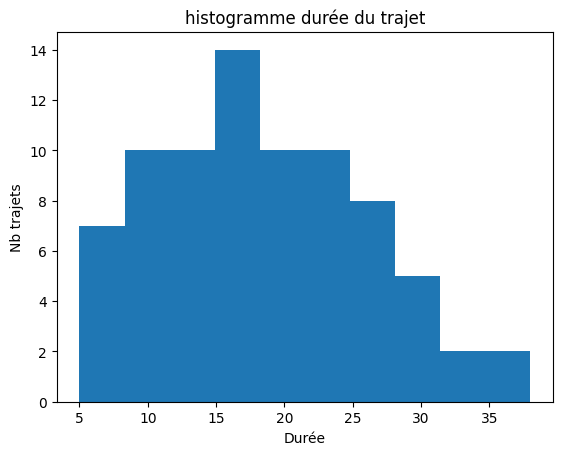

In [17]:
# On décore un peu le graphique
plt.title("histogramme durée du trajet")
plt.xlabel("Durée")
plt.ylabel("Nb trajets")

# On trace l'histogramme
plt.hist(df["duree_minutes"], bins = 10)

# Affichage de la figure
plt.show()

### Diagramme en barres par jour de la semaine

In [18]:
ordre_jours = ["lundi","mardi","mercredi","jeudi","vendredi","samedi","dimanche"]
# La sortie est un pandas.Series
df["jour_semaine"].value_counts()

jour_semaine
lundi       13
jeudi       13
mercredi    12
dimanche    12
mardi       11
samedi      11
vendredi    11
Name: count, dtype: int64

In [19]:
trajets_par_jour = df["jour_semaine"].value_counts().reindex(ordre_jours)
trajets_par_jour

jour_semaine
lundi       13
mardi       11
mercredi    12
jeudi       13
vendredi    11
samedi      11
dimanche    12
Name: count, dtype: int64

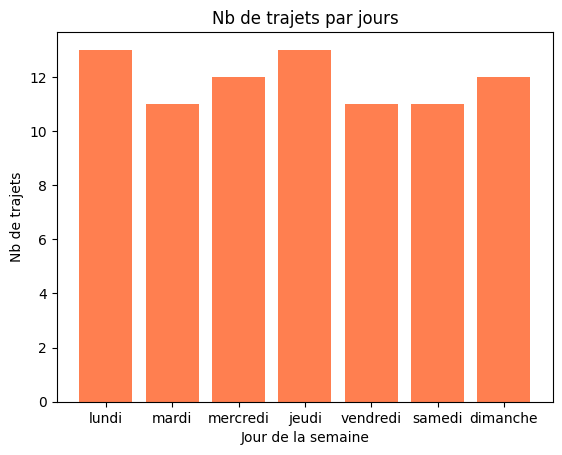

In [20]:
# Données d'exemple

# Création du graphique à barres
plt.bar(trajets_par_jour.index,trajets_par_jour.values, color = "coral")

# Ajout de titre et de labels
plt.title('Nb de trajets par jours')
plt.xlabel('Jour de la semaine')
plt.ylabel('Nb de trajets')

# Affichage de la figure (surtout utile, si MPL est utilisé de manière standalone)
plt.show()

### Nuage de points

In [21]:
df_clean['type_usager']

0          abonné
2          abonné
3     occasionnel
4          abonné
5          abonné
         ...     
75         abonné
76         abonné
77    occasionnel
78         abonné
79         abonné
Name: type_usager, Length: 75, dtype: str

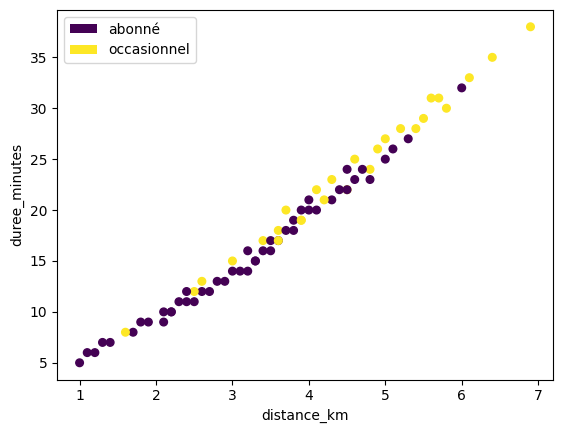

In [22]:
df_clean.plot.scatter(x='distance_km', y='duree_minutes', c = 'type_usager', s=30);

plt.show()

In [26]:
for row in df.iterrows():
    print(row)

(0, trajet_id                   T001
station_depart     Gare Centrale
station_arrivee     Parc Lumière
type_usager               abonné
duree_minutes               14.0
distance_km                  3.2
heure_depart               08:32
jour_semaine               lundi
temperature_c               18.5
velo_id                     V042
Name: 0, dtype: object)
(1, trajet_id                 T002
station_depart      Université
station_arrivee            NaN
type_usager        occasionnel
duree_minutes              NaN
distance_km                1.8
heure_depart             13:15
jour_semaine          mercredi
temperature_c              NaN
velo_id                   V017
Name: 1, dtype: object)
(2, trajet_id                    T003
station_depart     Hôtel de Ville
station_arrivee     Gare Centrale
type_usager                abonné
duree_minutes                 9.0
distance_km                   2.1
heure_depart                07:48
jour_semaine                mardi
temperature_c               